# Scatter Chart

In [39]:
# Import Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading the Dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Sorting by Date
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Making job_skills a list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [40]:
# Selecting Data Scientist for this plot
df_DE = df[df['job_title_short']=='Data Scientist'].copy()\

# Exploding the job_skills
df_exploded = df_DE.explode('job_skills')

# Using group by creating median and skill count column
df_stats = df_exploded.groupby('job_skills').agg(median_salary=('salary_year_avg','median'), skill_count=('job_skills','count'))

# sorting the values
df_stats = df_stats.sort_values(by='skill_count',ascending=False).head(10)

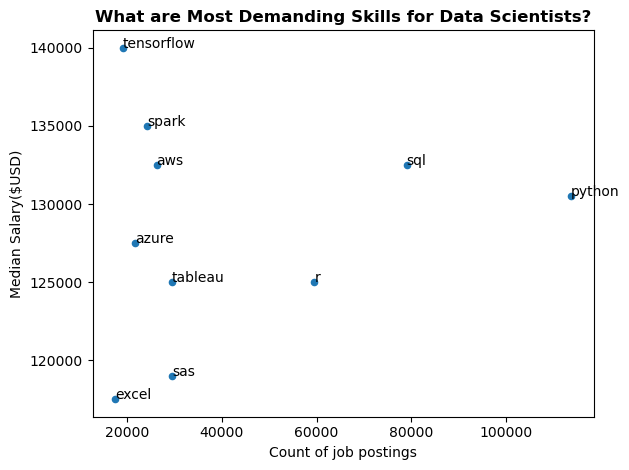

In [ ]:
# now lets plot the chart
df_stats.plot(kind='scatter',y='median_salary',x='skill_count')

for i, txt in enumerate(df_stats.index):
    plt.text(df_stats['skill_count'].iloc[i], df_stats['median_salary'].iloc[i], txt)

# now lets format it
plt.xlabel('Count of job postings')
plt.ylabel('Median Salary($USD)')
plt.title('What are Most Demanding Skills for Data Scientists?',fontweight='bold')
plt.tight_layout()
plt.show()
